# Part 2, Task 2 — Feature Engineering

Annotated walkthrough of `feature_engineering.py` — imports and calls the
same functions defined there (no logic duplicated here). Builds on the
cleaned dataset produced by `pipeline.py` / `pipeline_notebook.py`.

In [1]:
import sys
from pathlib import Path

import pandas as pd

_candidates = [Path.cwd(), Path.cwd() / "part2_python", Path.cwd().parent, Path.cwd().parent / "part2_python"]
for _c in _candidates:
    if (_c / "feature_engineering.py").exists():
        sys.path.insert(0, str(_c))
        break

import feature_engineering
import pipeline

if not __import__("logging").getLogger().handlers:
    pipeline.configure_logging("INFO")

# Make sure the cleaned dataset exists — run the pipeline if this notebook is
# executed on its own, before pipeline_notebook.py / pipeline.py has run.
if not feature_engineering.DEFAULT_INPUT.exists():
    print("cleaned_traffic_data.csv not found — running pipeline.run_pipeline() first...")
    pipeline.run_pipeline()

df = pd.read_csv(feature_engineering.DEFAULT_INPUT)
print(f"Loaded cleaned data: {df.shape}")
df.head()

Loaded cleaned data: (40575, 10)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,is_holiday
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,False
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,False
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,False
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,False
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,False


## 1. Time features — cyclical encoding

`hour` and `day_of_week` are extracted from `date_time`, plus a
`is_weekend` flag. Hour/day-of-week are also encoded as sine/cosine pairs
so a model sees hour 23 and hour 0 as adjacent (a plain integer 0-23
implies they're 23 apart, which is wrong).

In [2]:
df1 = feature_engineering.add_time_features(df)
df1[["date_time", "hour", "day_of_week", "is_weekend", "hour_sin", "hour_cos"]].head()

2026-09-15 11:50:35 | INFO     | feature_engineering | Added time features: hour, day_of_week, is_weekend, and cyclical sin/cos encodings for hour and day_of_week


,date_time,hour,day_of_week,is_weekend,hour_sin,hour_cos
0,2012-10-02 09:00:00,9,1,0,7.071068e-01,-0.707107
1,2012-10-02 10:00:00,10,1,0,5.000000e-01,-0.866025
2,2012-10-02 11:00:00,11,1,0,2.588190e-01,-0.965926
3,2012-10-02 12:00:00,12,1,0,1.224647e-16,-1.000000
4,2012-10-02 13:00:00,13,1,0,-2.588190e-01,-0.965926


## 2. Weather features — one-hot + derived indicators

`weather_main` is one-hot encoded, plus three derived binary indicators
(`is_severe_weather`, `is_low_visibility`, `has_precipitation`) that are
reused again in Part 3 for the proxy accident-risk label.

In [3]:
df2 = feature_engineering.add_weather_features(df1)
weather_cols = [c for c in df2.columns if c.startswith("weather_")] + [
    "is_severe_weather", "is_low_visibility", "has_precipitation"
]
df2[weather_cols].head()

2026-09-15 11:50:35 | INFO     | feature_engineering | Added weather features: 11 one-hot columns for weather_main, plus derived indicators is_severe_weather, is_low_visibility, has_precipitation


,weather_main,weather_description,weather_Clear,weather_Clouds,weather_Drizzle,weather_Fog,weather_Haze,weather_Mist,weather_Rain,weather_Smoke,weather_Snow,weather_Squall,weather_Thunderstorm,is_severe_weather,is_low_visibility,has_precipitation
0,Clouds,scattered clouds,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,Clouds,broken clouds,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,Clouds,overcast clouds,0,1,0,0,0,0,0,0,0,0,0,0,0,0
3,Clouds,overcast clouds,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,Clouds,broken clouds,0,1,0,0,0,0,0,0,0,0,0,0,0,0


## 3. Scaled numeric features

`temp` and `clouds_all` are min-max scaled to [0, 1], implemented directly
with NumPy/pandas here for transparency (Part 3 uses sklearn's
`StandardScaler` where a fitted, reusable scaler object is actually needed).

In [4]:
df3 = feature_engineering.add_scaled_numeric_features(df2)
df3[["temp", "temp_scaled", "clouds_all", "clouds_all_scaled"]].describe()

2026-09-15 11:50:35 | INFO     | feature_engineering | Added min-max scaled versions of: temp, clouds_all


,temp,temp_scaled,clouds_all,clouds_all_scaled
count,40575.000000,40575.000000,40575.000000,40575.000000
mean,281.382237,0.569770,44.201528,0.442015
std,13.093825,0.196368,38.683697,0.386837
min,243.390000,0.000000,0.000000,0.000000
25%,271.840000,0.426665,1.000000,0.010000
50%,282.860000,0.591932,40.000000,0.400000
75%,292.280000,0.733203,90.000000,0.900000
max,310.070000,1.000000,100.000000,1.000000


## 4. Congestion category — data-driven quartiles

`traffic_volume` is bucketed into Low / Medium / High / Severe using its
own quartiles (not fixed thresholds), so the categories adapt automatically
if the corridor's traffic pattern shifts over time. This is the same
definition reused for Part 3's proxy accident-risk label.

In [5]:
df4 = feature_engineering.add_congestion_category(df3)
counts = df4["congestion_category"].value_counts().reindex(["Low", "Medium", "High", "Severe"])
print(counts)

2026-09-15 11:50:35 | INFO     | feature_engineering | Added data-driven 'congestion_category' (quartile-based): {'High': 10145, 'Medium': 10144, 'Low': 10144, 'Severe': 10142}
congestion_category
Low       10144
Medium    10144
High      10145
Severe    10142
Name: count, dtype: int64


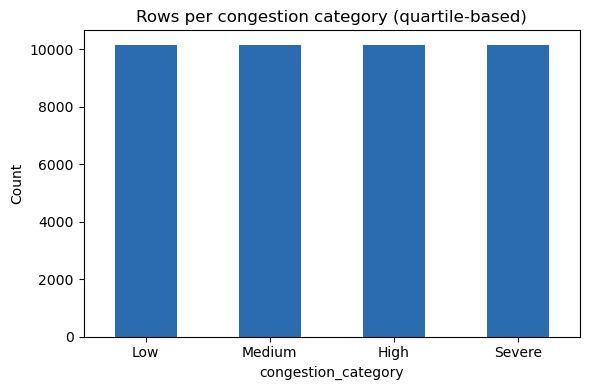

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax, color="#2b6cb0")
ax.set_title("Rows per congestion category (quartile-based)")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Confirm this matches `engineer_features()` exactly

`engineer_features()` runs all four steps above in sequence — this is the
function `main.py` and `cli_app/app.py` actually call.

In [7]:
df_check = feature_engineering.engineer_features(pd.read_csv(feature_engineering.DEFAULT_INPUT))
assert df_check.shape == df4.shape, "Shape mismatch between manual walkthrough and engineer_features()!"
assert list(df_check.columns) == list(df4.columns), "Column mismatch!"
print(f"Confirmed: engineer_features() output matches the step-by-step walkthrough above — shape {df_check.shape}.")

2026-09-15 11:50:35 | INFO     | feature_engineering | Feature engineering starting — input shape: 40575 rows x 10 columns
2026-09-15 11:50:35 | INFO     | feature_engineering | Added time features: hour, day_of_week, is_weekend, and cyclical sin/cos encodings for hour and day_of_week
2026-09-15 11:50:35 | INFO     | feature_engineering | Added weather features: 11 one-hot columns for weather_main, plus derived indicators is_severe_weather, is_low_visibility, has_precipitation
2026-09-15 11:50:35 | INFO     | feature_engineering | Added min-max scaled versions of: temp, clouds_all
2026-09-15 11:50:36 | INFO     | feature_engineering | Added data-driven 'congestion_category' (quartile-based): {'High': 10145, 'Medium': 10144, 'Low': 10144, 'Severe': 10142}
2026-09-15 11:50:36 | INFO     | feature_engineering | Feature engineering complete — output shape: 40575 rows x 34 columns
Confirmed: engineer_features() output matches the step-by-step walkthrough above — shape (40575, 34).


## Save the featured dataset

In [8]:
df_check.to_csv(feature_engineering.DEFAULT_OUTPUT, index=False)
print(f"Saved to {feature_engineering.DEFAULT_OUTPUT}  (shape {df_check.shape})")

Saved to C:\Users\farid\Course\Week 33\Capstone project\smart-city-traffic-capstone\smart-city-traffic-capstone\part2_python\featured_traffic_data.csv  (shape (40575, 34))
